In [1]:
import os
import json
import struct
import numpy as np
from PIL import Image

# 1. NASTAVITVE
BITMAP_DIR = r'F:\FRI_DIPLOMSKA\-delovna mapa-\DATASET\dataset\bitmaps'
STROKE_DIR = r'F:\FRI_DIPLOMSKA\-delovna mapa-\DATASET\dataset\strokes'
TEST_OSEBE = ['1009', 'pika', 'K']
MAX_STROKES = 5
POINTS_PER_STROKE = 32

labels_ordered = ['A', 'B', 'C', 'Č', 'D', 'E', 'F', 'G', 'H', 'I',
                  'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'Š',
                  'T', 'U', 'V', 'Z', 'Ž']
label_to_idx = {l: i for i, l in enumerate(labels_ordered)}




##################################################
def resample_stroke(points, max_strokes=MAX_STROKES, points_per_stroke=POINTS_PER_STROKE):
    strokes = []
    current = []
    for p in points:
        if p['x'] == -1:
            if current:
                strokes.append(current)
                current = []
        else:
            current.append((p['x'], p['y']))
    if current:
        strokes.append(current)
    if not strokes:
        return None

    all_pts = np.array([p for s in strokes for p in s])
    x_min, x_max = all_pts[:,0].min(), all_pts[:,0].max()
    y_min, y_max = all_pts[:,1].min(), all_pts[:,1].max()

    result = np.zeros((max_strokes, points_per_stroke, 2))
    for i, stroke in enumerate(strokes[:max_strokes]):
        if len(stroke) < 2:
            continue
        coords = np.array(stroke)
        distances = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
        cumdist = np.concatenate([[0], np.cumsum(distances)])
        total_dist = cumdist[-1]
        if total_dist == 0:
            continue
        sample_points = np.linspace(0, total_dist, points_per_stroke)
        xs = np.interp(sample_points, cumdist, coords[:,0])
        ys = np.interp(sample_points, cumdist, coords[:,1])
        xs = (xs - x_min) / (x_max - x_min + 1e-8)
        ys = (ys - y_min) / (y_max - y_min + 1e-8)
        result[i] = np.column_stack([xs, ys])

    return result.flatten()  # 320 vrednosti

##################################################
# 2. ZDRUŽENO NALAGANJE TESTNE ZBIRKE
##################################################
X_test_bitmaps = []
X_test_strokes = []
y_test = []

# Vzamemo vse .png datoteke in jih sortiramo za konsistentnost
vse_slike = sorted([f for f in os.listdir(BITMAP_DIR) if f.endswith('.png')])

for png_file in vse_slike:
    parts = png_file.split('_')
    crka = parts[0]
    oseba = parts[1] if len(parts) > 1 else 'unknown'
    
    # Samo testne osebe
    if oseba not in TEST_OSEBE:
        continue
        
    json_file = png_file.replace('.png', '.json')
    json_path = os.path.join(STROKE_DIR, json_file)
    
    # Preverimo, če obstaja tudi json (par)
    if not os.path.exists(json_path):
        continue
        
    # --- PROCESIRAJ STROKES ---
    with open(json_path, 'r') as f:
        points = json.load(f)
    resampled = resample_stroke(points)
    
    # Če je stroke neveljaven, preskočimo OBODVOJE!
    if resampled is None:
        continue
        
    # --- PROCESIRAJ BITMAPS ---
    img = Image.open(os.path.join(BITMAP_DIR, png_file)).convert('L')
    pixels = np.array(img, dtype=np.float32) / 255.0
    
    # Shranimo v skupne sezname (zdaj smo 100% prepričani, da sta oba ok)
    X_test_bitmaps.append(pixels.flatten())
    X_test_strokes.append(resampled)
    y_test.append(label_to_idx[crka])
    
##################################################
# 3. IZVOZ V .BIN 
##################################################
# Izvoz Bitmaps
with open(r"F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\bitmaps\zbirka_bitmaps_golden.bin", "wb") as fb:
    for i in range(len(y_test)):
        data_b = struct.pack('<BH784f', y_test[i], 784, *X_test_bitmaps[i].astype(np.float32))
        fb.write(data_b)

# Izvoz Strokes
with open(r"F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\strokes\zbirka_strokes_golden.bin", "wb") as fs:
    for i in range(len(y_test)):
        data_s = struct.pack('<BH320f', y_test[i], 160, *X_test_strokes[i].astype(np.float32))
        fs.write(data_s)

print(f"BINGO! Uspešno izvoženih {len(y_test)} popolnoma sinhroniziranih parov vzorcev.")

BINGO! Uspešno izvoženih 225 popolnoma sinhroniziranih parov vzorcev.


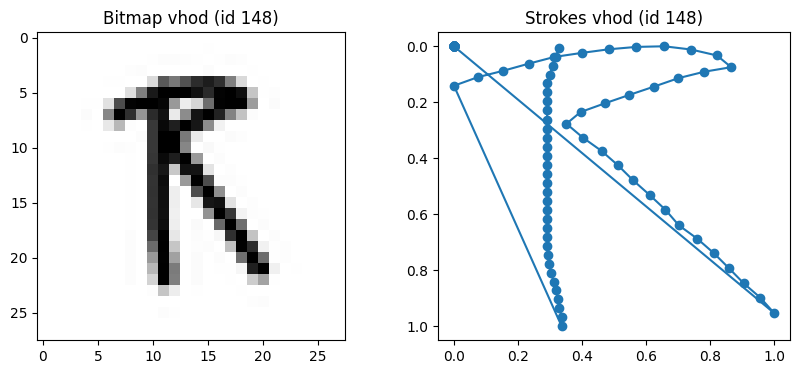

In [4]:
import matplotlib.pyplot as plt

def visualize_pair(idx, X_bitmaps, X_strokes):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # 1. Izris Bitmaps (28x28)
    axes[0].imshow(X_bitmaps[idx].reshape(28, 28), cmap='gray')
    axes[0].set_title(f"Bitmap vhod (id {idx})")
    
    # 2. Izris Strokes (320 floatov = 160 točk)
    pts = X_strokes[idx].reshape(-1, 2)
    axes[1].plot(pts[:,0], pts[:,1], 'o-')
    axes[1].set_title(f"Strokes vhod (id {idx})")
    axes[1].invert_yaxis() # Ker ima zaslon y=0 zgoraj
    
    plt.show()

# Kličeš tako:
visualize_pair(148, X_test_bitmaps, X_test_strokes)

In [7]:
IDX = 148  # ← spremeni po želji
SVG_POT = r'F:\FRI_DIPLOMSKA\-delovna mapa-\JUPY\ektorji_za_latex' + f'\\goldem_pair_{IDX}.pdf'

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Bitmap
axes[0].imshow(X_test_bitmaps[IDX].reshape(28, 28), cmap='gray', interpolation='nearest')
#axes[0].set_title('Statična črka', fontsize=10)
axes[0].axis('off')

# Strokes
pts = X_test_strokes[IDX].reshape(MAX_STROKES, POINTS_PER_STROKE, 2)
for stroke in pts:
    if stroke.sum() == 0:
        continue
    axes[1].plot(stroke[:, 0], stroke[:, 1], 'o-', linewidth=2, markersize=2, color='black')
#axes[1].set_title('Dinamična črka', fontsize=10)
axes[1].invert_yaxis()
axes[1].axis('off')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(SVG_POT, format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

print(f"Shranjeno: {SVG_POT}")

Shranjeno: F:\FRI_DIPLOMSKA\-delovna mapa-\JUPY\ektorji_za_latex\goldem_pair_148.pdf
